# Функция
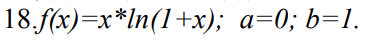

### Задание 1
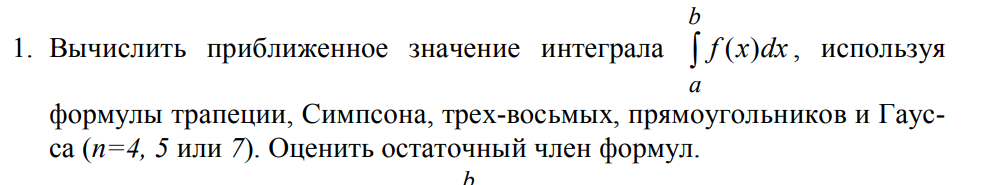

In [4]:
import math

a = 0.0
b = 1.0
exact_value = 0.25
n_task1 = 6

# 1. Заданная функция
def f(x):
    # x * ln(1+x)
    return x * math.log(1+x)

# 2. Инструменты для производных
def numerical_derivative_n(func, x, order, h=0.001):
    """Рекурсивное вычисление производной n-го порядка"""
    if order == 0:
        return func(x)
    val_plus = numerical_derivative_n(func, x + h, order - 1, h)
    val_minus = numerical_derivative_n(func, x - h, order - 1, h)
    return (val_plus - val_minus) / (2 * h)

def get_max_derivative(func, a, b, order, steps=100):
    """
    Ищет максимум модуля производной порядка 'order' на отрезке [a,b]
    """
    max_val = 0.0
    step = (b - a) / steps
    
    # Подбор шага h для дифференцирования в зависимости от порядка
    if order == 2:
        diff_h = 1e-4
    elif order == 4:
        diff_h = 1e-3 # Для 4-й производной нужен шаг покрупнее
    else:
        diff_h = 1e-4

    current_x = a
    for _ in range(steps + 1):
        # Защита от выхода за пределы области определения логарифма (x > -1)
        # На [0,1] проблем нет, но на всякий случай
        if current_x <= -1: 
            current_x += step
            continue
            
        val = abs(numerical_derivative_n(func, current_x, order, h=diff_h))
        if val > max_val:
            max_val = val
        current_x += step
        
    return max_val

# 3. Методы интегрирования (без изменений)
def rectangle_method(a,b,n):
    h = (b-a) / n 
    res = 0
    for i in range(n):
        x_mid  = a + h * (i + 0.5)
        res += f(x_mid)
    return res * h

def trapezoidal_method(a,b,n):
    h = (b-a) / n 
    res = 0.5 * (f(a) + f(b))
    for i in range(1,n):
        res += f(a + i * h)
    return res * h 

def simpson_method(a,b,n):
    if n % 2 != 0: n += 1
    h = (b - a) / n
    res = f(a) + f(b)
    for i in range(1,n):
        x = a + i * h
        if i % 2 == 0: res += 2 * f(x)
        else: res += 4 * f(x)
    return res * (h / 3) 

def simpson_3_8_method(a,b,n):
    if n % 3 != 0: n += (3 - n % 3)
    h = (b-a) / n
    res = f(a) + f(b)
    for i in range(1,n):
        x = a + i * h
        if i % 3 == 0: res += 2 * f(x)
        else: res += 3 * f(x)
    return res * (3 * h / 8)

def gauss_method(a,b,n):
    if n == 4:
        t = [-0.86113631, -0.33998104, 0.33998104, 0.86113631]
        w = [0.34785484, 0.65214516, 0.65214516, 0.34785484]
    elif n == 5:
        t = [-0.90617985, -0.53846931, 0.0, 0.53846931, 0.90617985]
        w = [0.23692688, 0.47862868, 0.56888889, 0.47862868, 0.23692688]
    else: return 0.0

    res = 0
    mid = 0.5 * (a + b)
    diff = 0.5 * (b-a)
    for i in range(len(t)):
        x_val = mid + diff * t[i]
        res += w[i] * f(x_val)
    return res * diff

M2 = get_max_derivative(f, a, b, order=2)
M4 = get_max_derivative(f, a, b, order=4)
print(f"Найдено: M2 ≈ {M2:.4f}, M4 ≈ {M4:.4f}")

def main():

    val_rect = rectangle_method(a,b,n_task1)
    val_trap = trapezoidal_method(a,b,n_task1)
    val_simp = simpson_method(a,b,n_task1)
    val_simp38 = simpson_3_8_method(a,b,n_task1)
    val_gauss = gauss_method(a,b, 4)
    
    # Формулы погрешностей
    # Для средних прямоугольников: M2 * (b-a)^3 / (24 * n^2)
    err_theory_rect = (M2 * (b - a)**3) / (24 * n_task1**2)
    
    # Для трапеций: M2 * (b-a)^3 / (12 * n^2)
    err_theory_trap = (M2 * (b - a)**3) / (12 * n_task1**2)
    
    # Для Симпсона: M4 * (b-a)^5 / (180 * n^4)
    err_theory_simp = (M4 * (b - a)**5) / (180 * n_task1**4)

    # Формула: M4 * (b-a)^5 / 80 * n^4
    err_theory_simp38 = (M4 * (b - a)**5) / (80 * n_task1**4)

    print(f"{'Метод':<20} | {'Значение':<10} | {'Теор. ошибка':<15} | {'Реал. ошибка':<15}")
    print("-" * 70)
    print(f"{'Прямоугольников':<20} | {val_rect:.6f}   | {err_theory_rect:.2e}        | {abs(val_rect - exact_value):.2e}")
    print(f"{'Трапеций':<20} | {val_trap:.6f}   | {err_theory_trap:.2e}        | {abs(val_trap - exact_value):.2e}")
    print(f"{'Симпсона (1/3)':<20} | {val_simp:.6f}   | {err_theory_simp:.2e}        | {abs(val_simp - exact_value):.2e}")
    print(f"{'Симпсона (3/8)':<20} | {val_simp38:.6f}   | {err_theory_simp38:.2e}        | {abs(val_simp38 - exact_value):.2e}")
    print(f"{'Гаусса (n=4)':<20} | {val_gauss:.8f} | {'(оч. малая)':<15} | {abs(val_gauss - exact_value):.2e}")

if __name__ =="__main__":
    main()


Найдено: M2 ≈ 2.0000, M4 ≈ 8.0001
Метод                | Значение   | Теор. ошибка    | Реал. ошибка   
----------------------------------------------------------------------
Прямоугольников      | 0.248621   | 2.31e-03        | 1.38e-03
Трапеций             | 0.252759   | 4.63e-03        | 2.76e-03
Симпсона (1/3)       | 0.250010   | 3.43e-05        | 1.03e-05
Симпсона (3/8)       | 0.250023   | 7.72e-05        | 2.25e-05
Гаусса (n=4)         | 0.24999984 | (оч. малая)     | 1.64e-07


### Задание 2
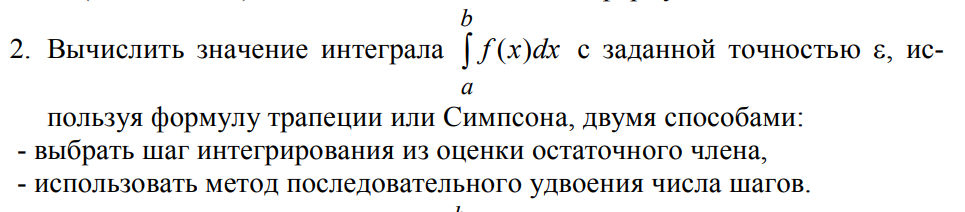

In [11]:
eps = 1e-5
a = 0.0
b = 1.0
exact_value = 0.25


def main():
    
    # Способ 1:
    # Теоретический расчет шага (для Симпсона)
    # n >= корень_4_степени( (M4*(b-a)^5) / (180*eps) )
    num = M4 * (b - a)**5
    denominator = 180 * eps
    n_theory = math.ceil((num / denominator)**0.25)
    
    if n_theory % 2 != 0:
        n_theory += 1  
    
    val_theory = simpson_method(a,b,n_theory)
    
    print(f"\n[1] Теоретический расчет (Симпсон): \n")
    print(f"Требуемое n = {n_theory}")
    print(f"Результат = {val_theory:.8f} (Ошибка: {abs(val_theory - exact_value):.2e})")
    
    # Способ 2:
    # Метод последовательного удвоения числа шагов

    n_runge = 2
    while True:
        I_n = simpson_method(a,b,n_runge)
        I_2n = simpson_method(a,b,n_runge * 2)
        
        error_runge = abs(I_2n - I_n) / 15.0
        
        if error_runge <= eps:
            print(f"\n[2] Метод последовательного удвоения числа шагов: \n")
            print(f"Остановка на n = {n_runge * 2}")
            print(f"Результат = {I_2n:.8f}")
            print(f"Оценка погрешности = {error_runge:.2e}")
            break
        
        n_runge *= 2
    

main()


[1] Теоретический расчет (Симпсон): 

Требуемое n = 10
Результат = 0.25000137 (Ошибка: 1.37e-06)

[2] Метод последовательного удвоения числа шагов: 

Остановка на n = 8
Результат = 0.25000332
Оценка погрешности = 3.13e-06
